# Annotation Statistics — MEL

Notebook for analyzing human annotations of the *Multimodal Entity Linking* dataset.
Annotation task: for each instance (a **mention** + an **image** + an **entity**),
the annotator answers `entity_is_illustrated` → **YES / NO**.

The notebook is **generic over N annotators**: just drop a new folder in
`Annotation/<user>/user_state.json` and everything recomputes.

**Outline**
- §0 — Loading the data
- §1 — Linking the sources (`master` table)
- §2 — General statistics
- §3 — Per-annotator statistics (agreement, bias, Cohen κ)
- §4 — Per-category statistics (PERS / ORG / LOC)
- §5 — Category × annotator
- §6 — Extreme cases (disagreements, fragile, unanimous) with images
- §7 — Fleiss κ / Krippendorff α (useful with 3+ annotators)
- §8 — Summary & validation


## §0 — Loading the data

In [ ]:
ANNOTATION_DIR = "/Users/thderrie/Desktop/These/Dataset_builder_MEL/output/annot_output"
DATA_DIR = "/Users/thderrie/Desktop/These/Dataset_builder_MEL/output/split_10_text"

In [2]:
import json, glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 200)

# --- Data root: adjust if needed (folder containing Data/ and Annotation/) ---
CANDIDATES = [Path("Annotation_V2"), Path("."), Path(".."), Path("Annotation_V2/Annotation_V2")]
ROOT = next((p for p in CANDIDATES if (p/"Data").exists() and (p/"Annotation").exists()), Path("."))
DATA, ANN = ROOT/"Data", ROOT/"Annotation"
print("ROOT =", ROOT.resolve())

def read_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]


ROOT = /Users/thderrie/Desktop/These/Dataset_builder_MEL/annotation


In [3]:
# KB: keep only what we need (type / name / desc / image) to avoid loading 114 MB into RAM
qid2type, qid2name, qid2desc, qid2img = {}, {}, {}, {}

# Ajout de encoding="utf-8"
with open(DATA/"kb.jsonl", encoding="utf-8") as f:
    for line in f:
        o = json.loads(line)
        qid2type[o["qid"]] = o["type"]
        qid2name[o["qid"]] = o.get("name")
        qid2desc[o["qid"]] = o.get("desc")
        qid2img[o["qid"]]  = o.get("infobox_img")

kb_types = Counter(qid2type.values())
print("KB:", sum(kb_types.values()), "entities —", dict(kb_types))

FileNotFoundError: [Errno 2] No such file or directory: 'Data/kb.jsonl'

In [15]:
by_id = {}

# Ouverture simultanée des deux fichiers
with open(DATA / "items.jsonl", "r", encoding="utf-8") as f_items, \
     open(DATA / "instances.jsonl", "r", encoding="utf-8") as f_insts:
    
    for line_item, line_inst in zip(f_items, f_insts):
        it = json.loads(line_item)
        ins = json.loads(line_inst)
        
        # On récupère l'ID, avec une sécurité au cas où il serait manquant
        item_id = it.get("id")
        if item_id is not None:
            by_id[item_id] = {
                "instance_id": item_id,
                "mention": it.get("mention"),
                "entity_name": it.get("entity_name"),
                "qid": it.get("qid"),
                "category": qid2type.get(it.get("qid")),
                "desc": qid2desc.get(it.get("qid")) or it.get("entity_desc"),
                "image_url": it.get("image_url"),
                "n_text_candidates": len(ins.get("text_candidates", [])),
                "n_visual_candidates": len(ins.get("visual_candidates", [])),
                "n_alternatives": len(it.get("alternatives", [])),
                "candidate_qids": list(dict.fromkeys(
                    ins.get("text_candidates", []) + ins.get("visual_candidates", [])
                )),
            }

print(len(by_id), "items indexed")

5251 items indexed


In [16]:
# Annotations: generic over N annotators (glob on Annotation/*/user_state.json)
def load_annotations():
    out = {}
    for path in sorted(glob.glob(str(ANN/"*"/"user_state.json"))):
        d = json.load(open(path))
        user = d.get("user_id") or Path(path).parent.name
        labels = {}
        for iid, val in d["instance_id_to_label_to_value"].items():
            try:
                labels[iid] = val[0][0]["name"]   # 'YES' / 'NO' / 'UNCERTAIN'
            except Exception:pass
        out[user] = labels
    return out

annotations = load_annotations()
ANNOTATORS = sorted(annotations.keys())
print("Annotators:", {u: len(v) for u, v in annotations.items()})


Annotators: {'Louis': 50, 'thomas': 18}


## §1 — Linking the sources → `master` table

Linking chain: `annotation.instance_id == item.id` → `item.qid` → `kb` (category),
and `items ↔ instances` by position. We produce **one row per annotated instance**, with
one label column per annotator plus derived columns (votes, majority, agreement).

In [17]:
all_ids = sorted(set().union(*[set(v) for v in annotations.values()]))

rows = []
for iid in all_ids:
    r = dict(by_id[iid])
    for u in ANNOTATORS:
        r[u] = annotations[u].get(iid, np.nan)
    votes = [r[u] for u in ANNOTATORS if isinstance(r[u], str)]
    r["n_votes"] = len(votes)
    r["n_yes"]   = votes.count("YES")
    r["n_no"]    = votes.count("NO")
    r["is_multi"]  = r["n_votes"] >= 2
    r["disagree"]  = (r["n_yes"] > 0 and r["n_no"] > 0)
    if   r["n_yes"] > r["n_no"]: r["majority"] = "YES"
    elif r["n_no"] > r["n_yes"]: r["majority"] = "NO"
    else:                        r["majority"] = "TIE"
    r["unanimous"] = (not r["disagree"]) and r["n_votes"] >= 1
    rows.append(r)

master = pd.DataFrame(rows)
print("master:", master.shape)
master.head()


master: (50, 20)


,instance_id,mention,entity_name,qid,category,desc,image_url,n_text_candidates,n_visual_candidates,n_alternatives,candidate_qids,Louis,thomas,n_votes,n_yes,n_no,is_multi,disagree,majority,unanimous
0,0a582f99bdf27e02,Marana,Marana Regional Airport,Q1029543,LOC,airport,https://upload.wikimedia.org/wikipedia/commons/1/1f/AT-6C_Texans_in_flight_1943.jpg,3,4,2,"[Q1029543, Q141219, Q762743, Q15485832, Q3143668, Q6211442]",YES,NaN,1,1,0,False,False,YES,True
1,0f1cfb8885db466c,Mazari,Shireen M. Mazari,Q7498535,PERS,politician in Pakistan,https://upload.wikimedia.org/wikipedia/commons/a/a6/Imran_Khan_2012.jpg,2,2,1,"[Q138123, Q7498535, Q19667804]",NO,NO,2,0,2,True,False,NO,True
2,15c2636e9a3109cb,Prozor,Prozor Fortress,Q7252924,ORG,"fortress in Dalmatia, Croatia",https://upload.wikimedia.org/wikipedia/commons/7/7f/Hrvoje_Vukcic_Hrvatinic.jpg,2,2,1,"[Q19904667, Q7252924, Q965696]",NO,NO,2,0,2,True,False,NO,True
3,166e71be1cffd9c6,Edward Perry,Edward Perry Warren,Q5344835,PERS,American art collector,https://upload.wikimedia.org/wikipedia/commons/3/39/Lewes_House%2C_2017.jpg,3,2,2,"[Q362723, Q5344834, Q5344835, Q18534199]",NO,NaN,1,0,1,False,False,NO,True
4,1d8f0dffe78ef5ef,Kvinnherad,Kvinnherad Municipality,Q484070,ORG,"municipality in Vestland, Norway",https://upload.wikimedia.org/wikipedia/commons/d/df/Halsn%C3%B8y_Kloster.jpg,2,2,1,"[Q4578142, Q484070, Q4580749]",NO,NaN,1,0,1,False,False,NO,True


### Display helpers (images + votes)

Two functions reused throughout to show **concrete examples**: `show_cards`
(image + info + votes, for a few cases) and `show_table` (rich table with thumbnails,
to list many cases). Static: the images render when the notebook is opened.

In [18]:
def _vote_badges(row):
    out = []
    for u in ANNOTATORS:
        v = row[u]
        if not isinstance(v, str):
            continue
        color = "#1a7f37" if v == "YES" else ("#b91c1c" if v == "NO" else "#92660a")
        out.append(f'<span style="background:{color};color:#fff;border-radius:5px;'
                   f'padding:1px 7px;margin-right:5px;font-size:12px">{u}: {v}</span>')
    return " ".join(out)

def _candidate_strip(row):
    qids = row.get("candidate_qids") or []
    if len(qids) == 0:
        return ""
    chips = ""
    for q in qids:
        name = qid2name.get(q) or q
        img  = qid2img.get(q) or ""
        gold = (q == row["qid"])
        border = "2px solid #1a7f37" if gold else "1px solid #ddd"
        star   = "★ " if gold else ""
        chips += (f'<div style="text-align:center;width:82px;margin:4px">'
                  f'<img src="{img}" style="width:76px;height:76px;object-fit:cover;'
                  f'border-radius:6px;border:{border}" onerror="this.style.opacity=.2">'
                  f'<div style="font-size:11px;color:#333;margin-top:2px;line-height:1.15">{star}{name}</div></div>')
    return ('<div style="margin-top:8px">'
            '<div style="font-size:11px;color:#888;margin-bottom:2px">Possible candidates (★ = gold):</div>'
            f'<div style="display:flex;flex-wrap:wrap">{chips}</div></div>')

def show_cards(df, img_w=300, desc_len=260, title=None):
    if title:
        display(HTML(f"<h4 style='margin:8px 0'>{title} — {len(df)} cases</h4>"))
    if len(df) == 0:
        display(HTML("<i>No cases.</i>")); return
    html = ""
    for _, row in df.iterrows():
        desc = (row["desc"] or "")[:desc_len]
        html += f'''
        <div style="display:flex;gap:14px;border:1px solid #e5e5e5;border-radius:10px;
                    padding:12px;margin:10px 0;align-items:flex-start">
          <img src="{row['image_url']}" style="width:{img_w}px;border-radius:8px;flex:0 0 auto"
               onerror="this.style.opacity=.3;this.alt='image unavailable'">
          <div style="min-width:0">
            <div style="font-weight:700;font-size:15px">{row['mention']}
                 <span style="color:#666;font-weight:400">→ {row['entity_name']}
                 <span style="background:#eef;border-radius:4px;padding:0 6px">{row['category']}</span></span></div>
            <div style="margin:6px 0">{_vote_badges(row)}</div>
            <div style="color:#444;font-size:13px">{desc}…</div>
            {_candidate_strip(row)}
          </div>
        </div>'''
    display(HTML(html))

def show_table(df, img_w=90, desc_len=110, title=None):
    if title:
        display(HTML(f"<h4 style='margin:8px 0'>{title} — {len(df)} cases</h4>"))
    if len(df) == 0:
        display(HTML("<i>No cases.</i>")); return
    head = "".join(f"<th style='text-align:left;padding:4px 8px'>{c}</th>"
                   for c in ["image","mention","entity","cat.","votes","desc"])
    body = ""
    for _, row in df.iterrows():
        desc = (row["desc"] or "")[:desc_len]
        body += (f"<tr style='border-top:1px solid #eee'>"
                 f"<td style='padding:4px 8px'><img src='{row['image_url']}' style='width:{img_w}px;border-radius:4px'></td>"
                 f"<td style='padding:4px 8px;font-weight:600'>{row['mention']}</td>"
                 f"<td style='padding:4px 8px'>{row['entity_name']}</td>"
                 f"<td style='padding:4px 8px'>{row['category']}</td>"
                 f"<td style='padding:4px 8px'>{_vote_badges(row)}</td>"
                 f"<td style='padding:4px 8px;color:#555;font-size:12px'>{desc}…</td></tr>")
    display(HTML(f"<table style='border-collapse:collapse;font-size:13px'><tr>{head}</tr>{body}</table>"))


## §2 — General statistics

In [19]:
n = len(master)
mono = master[~master["is_multi"]]
multi = master[master["is_multi"]]
disagreements = master[master["disagree"]]

all_labels = pd.concat([master[u].dropna() for u in ANNOTATORS])
yes_global = 100 * (all_labels == "YES").mean()

print(f"Annotated instances            : {n}")
print(f"  · single-annotator (1 vote)  : {len(mono)}")
print(f"  · multi-annotator (>=2)      : {len(multi)}")
print(f"Disagreements (among multi)    : {len(disagreements)}  "
      f"({100*len(disagreements)/max(len(multi),1):.0f}% of multi)")
print(f"Real agreement (multi unanim.) : {len(multi)-len(disagreements)}/{len(multi)}")
print(f"Global YES rate (base rate)    : {yes_global:.0f}%  (on {len(all_labels)} labels)")
print()
print("Majority label:", dict(master["majority"].value_counts()))
print("Category breakdown:", dict(master["category"].value_counts()))


Annotated instances            : 50
  · single-annotator (1 vote)  : 32
  · multi-annotator (>=2)      : 18
Disagreements (among multi)    : 4  (22% of multi)
Real agreement (multi unanim.) : 14/18
Global YES rate (base rate)    : 53%  (on 68 labels)

Majority label: {'YES': np.int64(26), 'NO': np.int64(20), 'TIE': np.int64(4)}
Category breakdown: {'PERS': np.int64(23), 'ORG': np.int64(15), 'LOC': np.int64(12)}


> ⚠️ **Key point** — of the 50 instances, only a minority are annotated by 2 people.
> A "unanimous" instance with **a single voter** is not a consensus: so we separate
> *single-annotator* and *multi-annotator* everywhere. Real agreement/disagreement only
> lives on the multi ones.

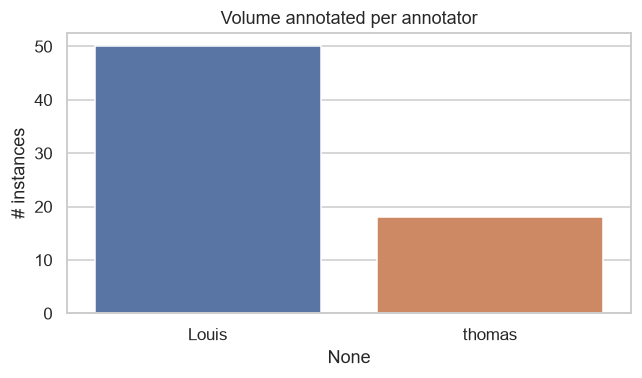

In [20]:
# Volume annotated per annotator
vol = pd.Series({u: master[u].notna().sum() for u in ANNOTATORS}).sort_values(ascending=False)
plt.figure(figsize=(6, 3.6))
sns.barplot(x=vol.index, y=vol.values, hue=vol.index, legend=False)
plt.title("Volume annotated per annotator"); plt.ylabel("# instances")
plt.tight_layout(); plt.show()


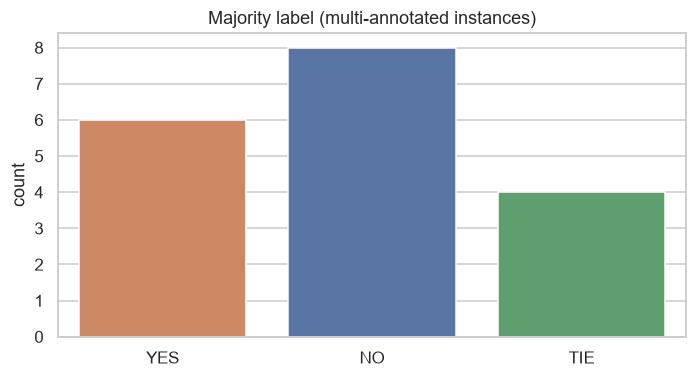

In [21]:
# Majority label on multi-annotated instances only
multi = master[master["is_multi"]]
plt.figure(figsize=(6.5, 3.6))
sns.countplot(data=multi, x="majority", order=["YES", "NO", "TIE"],
              hue="majority", legend=False)
plt.title("Majority label (multi-annotated instances)")
plt.xlabel(""); plt.tight_layout(); plt.show()


### Label breakdown — YES / NO / not annotated
Per annotator, out of all annotated instances: how many YES, how many NO, and how many
were left un-annotated by that person (their coverage gap).

,YES,NO,not annotated
Louis,29,21,0
thomas,7,11,32


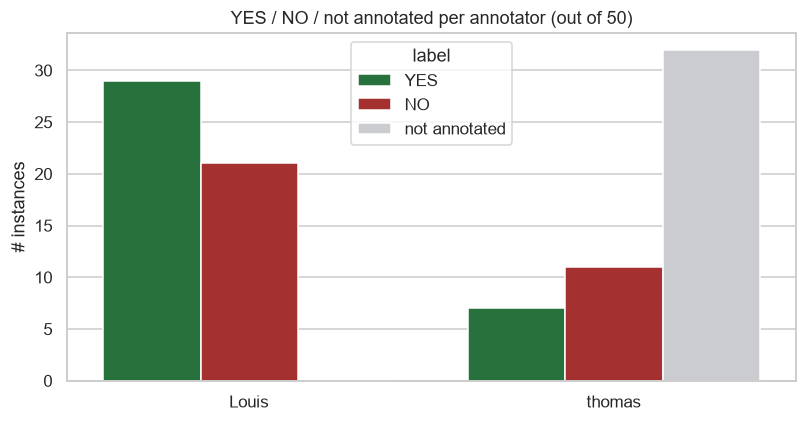

In [22]:
# Per-annotator counts: YES / NO / not annotated (out of all instances in master)
N = len(master)
counts = pd.DataFrame({
    "YES":           {u: int((master[u]=="YES").sum()) for u in ANNOTATORS},
    "NO":            {u: int((master[u]=="NO").sum())  for u in ANNOTATORS},
    "not annotated": {u: int(master[u].isna().sum())   for u in ANNOTATORS},
})
display(counts)

PAL3 = {"YES":"#1a7f37", "NO":"#b91c1c", "not annotated":"#c9ccd1"}
long_counts = counts.reset_index().melt(id_vars="index", var_name="label", value_name="count")
plt.figure(figsize=(7.5, 4))
sns.barplot(data=long_counts, x="index", y="count", hue="label", palette=PAL3)
plt.title(f"YES / NO / not annotated per annotator (out of {N})")
plt.xlabel(""); plt.ylabel("# instances"); plt.tight_layout(); plt.show()


{'YES': 36, 'NO': 32, 'not annotated': 32} | total cells = 100


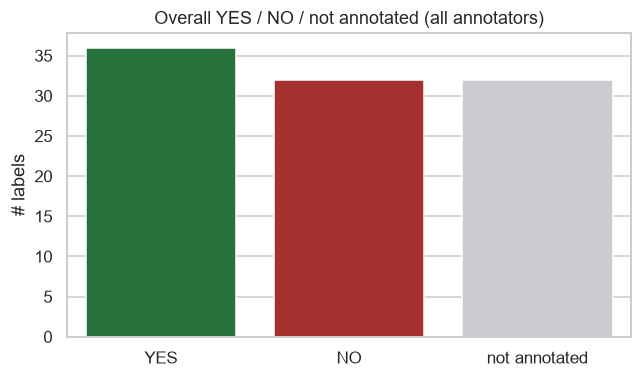

In [23]:
# Overall totals across all annotator × instance cells
totals = pd.Series({
    "YES":           int(sum((master[u]=="YES").sum() for u in ANNOTATORS)),
    "NO":            int(sum((master[u]=="NO").sum()  for u in ANNOTATORS)),
    "not annotated": int(sum(master[u].isna().sum()   for u in ANNOTATORS)),
})
print(totals.to_dict(), "| total cells =", N*len(ANNOTATORS))
plt.figure(figsize=(6, 3.6))
sns.barplot(x=totals.index, y=totals.values, hue=totals.index, legend=False,
            palette={"YES":"#1a7f37","NO":"#b91c1c","not annotated":"#c9ccd1"})
plt.title("Overall YES / NO / not annotated (all annotators)")
plt.ylabel("# labels"); plt.xlabel(""); plt.tight_layout(); plt.show()


## §3 — Per-annotator statistics

,n,YES,NO,yes_rate,no_rate,bias_yes,bias_no
Louis,50,29,21,58.0,42.0,5.1,-5.1
thomas,18,7,11,38.9,61.1,-14.0,14.0


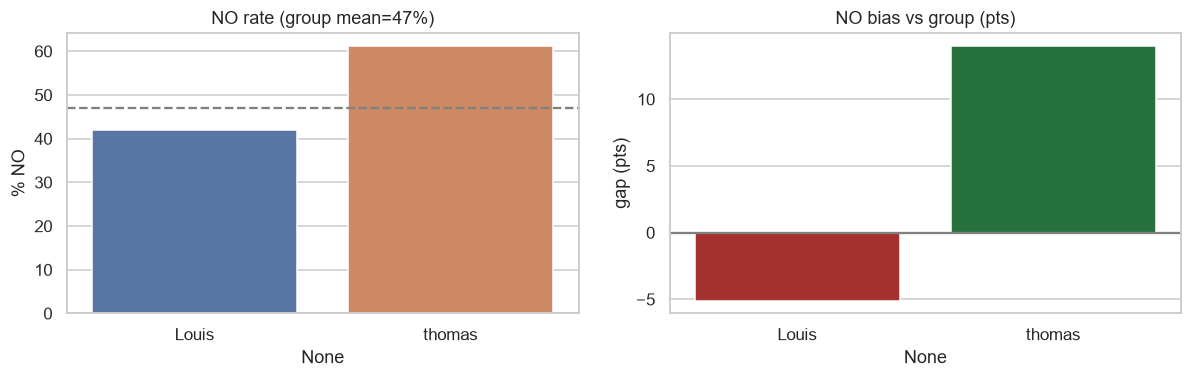

In [24]:
# YES/NO rates and bias (gap vs group mean). NO is the mirror of YES.
per_ann = pd.DataFrame({
    "n":   {u: master[u].notna().sum() for u in ANNOTATORS},
    "YES": {u: (master[u]=="YES").sum() for u in ANNOTATORS},
    "NO":  {u: (master[u]=="NO").sum()  for u in ANNOTATORS},
})
per_ann["yes_rate"] = (100*per_ann["YES"]/per_ann["n"]).round(1)
per_ann["no_rate"]  = (100*per_ann["NO"] /per_ann["n"]).round(1)
group_yes = 100*per_ann["YES"].sum()/per_ann["n"].sum()
group_no  = 100*per_ann["NO"].sum() /per_ann["n"].sum()
per_ann["bias_yes"] = (per_ann["yes_rate"]-group_yes).round(1)
per_ann["bias_no"]  = (per_ann["no_rate"] -group_no ).round(1)
display(per_ann)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
# NO rate
sns.barplot(x=per_ann.index, y=per_ann["no_rate"], ax=ax[0], hue=per_ann.index, legend=False)
ax[0].axhline(group_no, ls="--", c="gray")
ax[0].set_title(f"NO rate (group mean={group_no:.0f}%)"); ax[0].set_ylabel("% NO")
# NO bias
colors = ["#1a7f37" if b>=0 else "#b91c1c" for b in per_ann["bias_no"]]
sns.barplot(x=per_ann.index, y=per_ann["bias_no"], ax=ax[1], palette=colors, hue=per_ann.index, legend=False)
ax[1].axhline(0, c="gray"); ax[1].set_title("NO bias vs group (pts)"); ax[1].set_ylabel("gap (pts)")
plt.tight_layout(); plt.show()


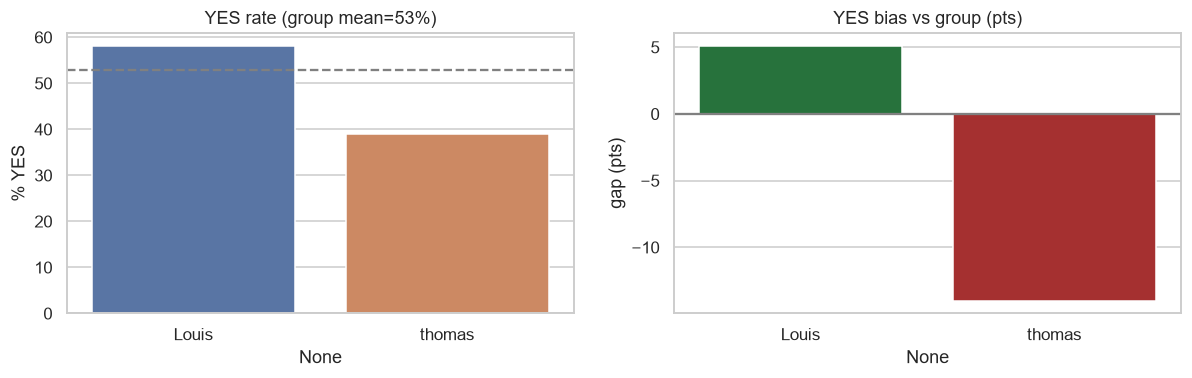

In [25]:
# YES rate and bias (mirror of NO), same layout
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
# YES rate
sns.barplot(x=per_ann.index, y=per_ann["yes_rate"], ax=ax[0], hue=per_ann.index, legend=False)
ax[0].axhline(group_yes, ls="--", c="gray")
ax[0].set_title(f"YES rate (group mean={group_yes:.0f}%)"); ax[0].set_ylabel("% YES")
# YES bias
colors = ["#1a7f37" if b>=0 else "#b91c1c" for b in per_ann["bias_yes"]]
sns.barplot(x=per_ann.index, y=per_ann["bias_yes"], ax=ax[1], palette=colors, hue=per_ann.index, legend=False)
ax[1].axhline(0, c="gray"); ax[1].set_title("YES bias vs group (pts)"); ax[1].set_ylabel("gap (pts)")
plt.tight_layout(); plt.show()


### Inter-annotator agreement — Cohen's κ (on shared instances)

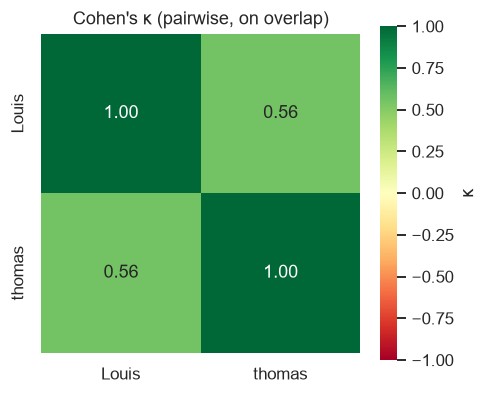

,Louis,thomas
Louis,1.000,0.556
thomas,0.556,1.000


In [26]:
from sklearn.metrics import cohen_kappa_score

def pairwise_kappa(df, users):
    K = pd.DataFrame(np.nan, index=users, columns=users, dtype=float)
    for a in users:
        for b in users:
            if a == b:
                K.loc[a, b] = 1.0; continue
            sub = df[df[a].notna() & df[b].notna()]
            if len(sub) >= 2:
                try: K.loc[a, b] = cohen_kappa_score(sub[a], sub[b])
                except Exception: pass
    return K

K = pairwise_kappa(master, ANNOTATORS)
plt.figure(figsize=(4.6, 3.8))
sns.heatmap(K.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, square=True, cbar_kws={"label":"κ"})
plt.title("Cohen's κ (pairwise, on overlap)"); plt.tight_layout(); plt.show()
K.round(3)


### Annotator confusion matrix (on shared instances)

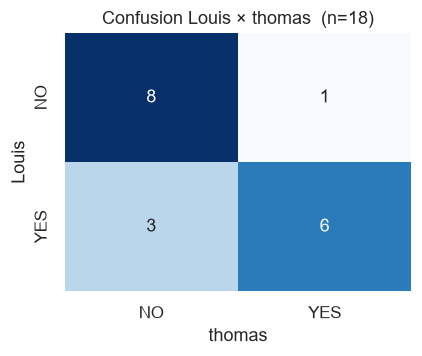

In [27]:
if len(ANNOTATORS) >= 2:
    a, b = ANNOTATORS[0], ANNOTATORS[1]
    sub = master[master[a].notna() & master[b].notna()]
    cm = pd.crosstab(sub[a], sub[b])
    plt.figure(figsize=(4, 3.4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion {a} × {b}  (n={len(sub)})"); plt.xlabel(b); plt.ylabel(a)
    plt.tight_layout(); plt.show()


#### Extreme examples — where annotators diverge
The shared instances where votes differ: this is where disagreement plays out.

In [28]:
show_cards(disagreements, title="Disagreements between annotators")


## §4 — Per-category statistics (PERS / ORG / LOC)

,n,n_multi,yes_rate,agreement_multi_%
category,,,,
LOC,12,3,73.0,100.0
ORG,15,5,35.0,100.0
PERS,23,10,55.0,60.0


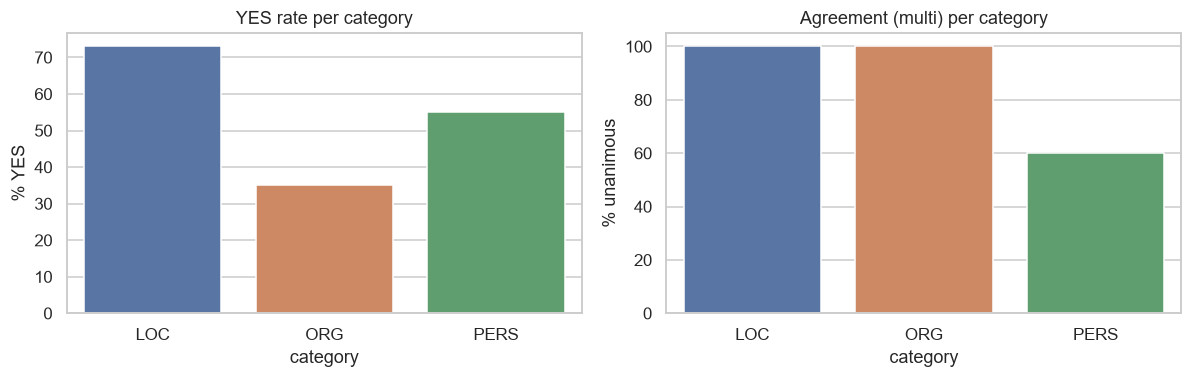

In [29]:
cat = master.groupby("category").agg(
    n=("instance_id","size"),
    n_multi=("is_multi","sum"),
    yes_rate=("n_yes", lambda s: 100*s.sum()/(master.loc[s.index,["n_yes","n_no"]].sum().sum())),
)
# real agreement rate = share of unanimous among the multi of the category
acc = {}
for c, g in master.groupby("category"):
    gm = g[g["is_multi"]]
    acc[c] = 100*(gm["unanimous"].sum())/len(gm) if len(gm) else np.nan
cat["agreement_multi_%"] = pd.Series(acc).round(0)
cat["yes_rate"] = cat["yes_rate"].round(0)
display(cat)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.barplot(x=cat.index, y=cat["yes_rate"], ax=ax[0], hue=cat.index, legend=False)
ax[0].set_title("YES rate per category"); ax[0].set_ylabel("% YES")
sns.barplot(x=cat.index, y=cat["agreement_multi_%"], ax=ax[1], hue=cat.index, legend=False)
ax[1].set_title("Agreement (multi) per category"); ax[1].set_ylabel("% unanimous")
plt.tight_layout(); plt.show()


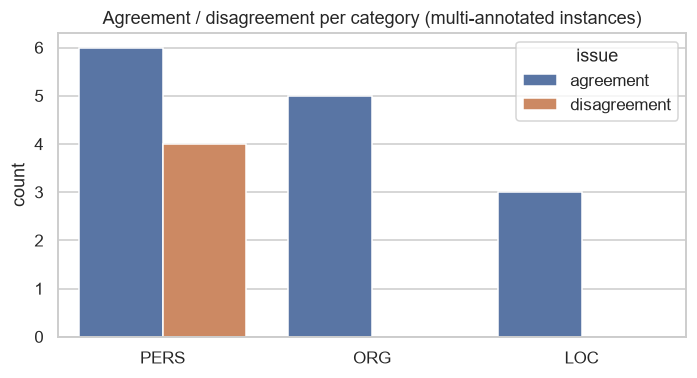

In [30]:
# Disagreement vs category (on the multi)
mm = multi.copy()
mm["issue"] = np.where(mm["disagree"], "disagreement", "agreement")
plt.figure(figsize=(6.5, 3.6))
sns.countplot(data=mm, x="category", hue="issue")
plt.title("Agreement / disagreement per category (multi-annotated instances)")
plt.xlabel(""); plt.tight_layout(); plt.show()


#### Extreme examples per category
For each category: the **clearest** case (unanimous) and, if any, a **borderline** case
(disagreement). This shows what an "easy" vs "contentious" data point looks like.

In [31]:
for c in sorted(master["category"].dropna().unique()):
    g = master[master["category"] == c]
    clean = g[(g["unanimous"]) & (g["is_multi"])]
    border = g[g["disagree"]]
    ex = pd.concat([clean.head(1), border.head(1)])
    if len(ex):
        show_cards(ex, img_w=240, title=f"Category {c}: clear vs borderline")


## §5 — Category × annotator

label               NO  YES
annotator category         
Louis     LOC        3    9
          ORG        9    6
          PERS       9   14
thomas    LOC        1    2
          ORG        4    1
          PERS       6    4

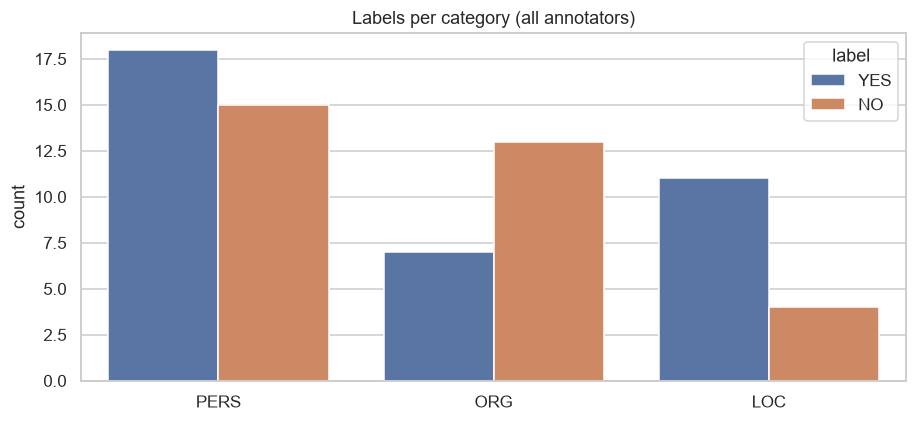

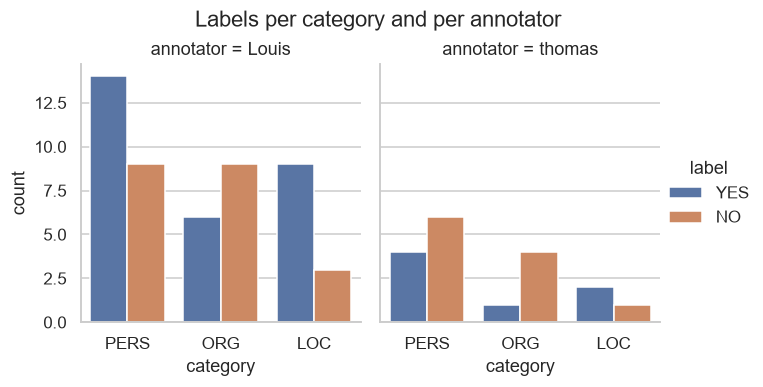

In [32]:
long = master.melt(id_vars=["instance_id","category"], value_vars=ANNOTATORS,
                    var_name="annotator", value_name="label").dropna(subset=["label"])
ct = pd.crosstab([long["annotator"], long["category"]], long["label"])
display(ct)

plt.figure(figsize=(8.5, 4))
sns.countplot(data=long, x="category", hue="label", order=["PERS","ORG","LOC"])
plt.title("Labels per category (all annotators)"); plt.xlabel(""); plt.tight_layout(); plt.show()

g = sns.catplot(data=long, x="category", hue="label", col="annotator",
                kind="count", order=["PERS","ORG","LOC"], height=3.4, aspect=.9)
g.fig.suptitle("Labels per category and per annotator", y=1.03); plt.show()


In [33]:
# κ per category (on the shared instances of each category)
if len(ANNOTATORS) >= 2:
    a, b = ANNOTATORS[0], ANNOTATORS[1]
    rowsk = []
    for c, gc in master.groupby("category"):
        sub = gc[gc[a].notna() & gc[b].notna()]
        k = cohen_kappa_score(sub[a], sub[b]) if len(sub) >= 2 and sub[a].nunique()*sub[b].nunique() else np.nan
        rowsk.append({"category": c, "n_common": len(sub), "kappa": round(k,3) if k==k else np.nan})
    display(pd.DataFrame(rowsk))
    print("(low n_common per category -> per-category κ is only indicative while we have 2 annotators)")


,category,n_common,kappa
0,LOC,3,1.000
1,ORG,5,1.000
2,PERS,10,0.231


(low n_common per category -> per-category κ is only indicative while we have 2 annotators)


## §6 — Extreme cases

### 6.1 — Disagreements (detailed cards)

In [34]:
show_cards(disagreements, img_w=320, desc_len=320, title="All disagreeing instances")


### 6.2 — Fragile instances
Instances where the outcome hinges on a single vote: **ties** (TIE) and margin-1 majorities.

In [35]:
master["margin"] = (master["n_yes"] - master["n_no"]).abs()
fragile = master[(master["is_multi"]) & (master["margin"] <= 1)].sort_values("margin")
show_cards(fragile, img_w=260, title="Fragile instances (margin <= 1)")


### 6.3 — Unanimous (list all)
All unanimous instances, separated **YES / NO** and **single / multi-annotator**.
Reminder: *single*-annotator ones are not a consensus, just a single opinion.

In [36]:
for cover, label in [("multi","YES"),("multi","NO"),("mono","YES"),("mono","NO")]:
    is_multi = cover == "multi"
    sub = master[(master["unanimous"]) & (master["is_multi"]==is_multi) & (master["majority"]==label)]
    if len(sub):
        show_table(sub, title=f"Unanimous {label} — {cover}-annotator")


image,mention,entity,cat.,votes,desc
,Yeshua,Jesus Christ,PERS,Louis: YES thomas: YES,central figure of Christianity (c. 6 or 4 BC – AD 30 or 33)…
,Sikandarabad,Secunderabad,ORG,Louis: YES thomas: YES,"twin city of Hyderabad, India…"
,Christian Moller,Christian Møller,PERS,Louis: YES thomas: YES,Danish scientist (1904–1980)…
,Rovina,Lago della Rovina,LOC,Louis: YES thomas: YES,lake…
,Ed Carpenter,Eddie Carpenter,PERS,Louis: YES thomas: YES,Canadian ice hockey defenceman (1890-1963)…
,Kemp,Kemps Corner,LOC,Louis: YES thomas: YES,"place in Maharashtra, India…"


image,mention,entity,cat.,votes,desc
,Mazari,Shireen M. Mazari,PERS,Louis: NO thomas: NO,politician in Pakistan…
,Prozor,Prozor Fortress,ORG,Louis: NO thomas: NO,"fortress in Dalmatia, Croatia…"
,River Dee,River Dee,LOC,Louis: NO thomas: NO,river in England and Wales…
,Chersonesus,Tauria,ORG,Louis: NO thomas: NO,"land of Tauris, Northeastern Black Sea Coast, South Coast of ancient Crimea, also known as the Tauric Chersone…"
,Sundara,Ajahn Sundara,PERS,Louis: NO thomas: NO,Monastic…
,Aleksandr Sergeyev,Alexander Sergeev,PERS,Louis: NO thomas: NO,Russian physicist…
,Gradište,Gradište,ORG,Louis: NO thomas: NO,village in Serbia…
,Suriname,Surinam,ORG,Louis: NO thomas: NO,Dutch plantation colony in the Guianas…


image,mention,entity,cat.,votes,desc
,Marana,Marana Regional Airport,LOC,Louis: YES,airport…
,Hyder,Hyder,LOC,Louis: YES,"ghost town in Yuma County, Arizona…"
,Verge,Jack Verge,PERS,Louis: YES,Australian rugby union player (1880-1915)…
,Sigismund of Lithuania,Sigismund III Vasa,PERS,Louis: YES,"King of Poland, Grand Duke of Lithuania and king of the Polish–Lithuanian Commonwealth from 1587 until 1632 an…"
,Onoba,Huelva,ORG,Louis: YES,"municipality and capital city of the Province of Huelva, Spain…"
,William Steuart,William Steuart,PERS,Louis: YES,American planter (1754–1839)…
,Ringebu,Ringebu Stave Church,LOC,Louis: YES,"church building in Ringebu, Innlandet, Norway…"
,Rozina,Rožina,ORG,Louis: YES,"village in Nišava District, Serbia…"
,Sleepy Hollow,Sleepy Hollow,LOC,Louis: YES,shallow depression on the planet Mars…
,Malay Kingdom,Melayu,ORG,Louis: YES,kingdom in Southeast Asia…


image,mention,entity,cat.,votes,desc
,Edward Perry,Edward Perry Warren,PERS,Louis: NO,American art collector…
,Kvinnherad,Kvinnherad Municipality,ORG,Louis: NO,"municipality in Vestland, Norway…"
,Sheen,East Sheen,LOC,Louis: NO,suburb of London in the London Borough of Richmond upon Thames…
,Gauda,Gauḍa,ORG,Louis: NO,ancient city in India and Bangladesh…
,Salo,Salò,ORG,Louis: NO,Italian comune…
,John Fane,"John Fane, 9th Earl of Westmorland",PERS,Louis: NO,English Earl…
,Kara Dag,Montenegro,ORG,Louis: NO,country in southeastern Europe…
,Indore,Indore district,ORG,Louis: NO,"district of Madhya Pradesh, India…"
,Whiteford,Whiteford Sands,LOC,Louis: NO,"beach on the northern side of the Gower Peninsula, south Wales…"
,Scipio Nasica,Publius Cornelius Scipio Nasica,PERS,Louis: NO,Ancient Roman conusl…


## §7 — Annotation time (behavioral logs)

Per-category and per-annotator **time spent annotating**, reconstructed from the Potato
behavioral logs (`instance_id_to_behavioral_data`).

**Metric — *decision time*.** For each instance we take the delay between the moment the
instance is shown (`navigation / instance_load`) and the **first** `annotation_change`.
This is the cleanest signal of effort: raw dwell time (load → last save) is polluted by
users leaving the tab open.

**Outlier handling — the "left the page open" problem.** Even the decision time can blow up
when someone walks away before clicking (e.g. thomas has one instance at ~1125&nbsp;s, Louis
one at ~526&nbsp;s). We therefore **winsorize**: values above Tukey's upper fence
(`Q3 + 1.5·IQR`, computed on the pooled distribution) are **capped** to that fence rather
than dropped, so the per-cell counts stay intact. Switch `CAP_METHOD` to `"p95"` or
`"none"` to compare.

In [37]:
# --- Decision time = instance_load -> first annotation_change ---------------
def _decision_time(beh):
    inter   = beh.get("interactions", [])
    loads   = [e["timestamp"] for e in inter
               if e["event_type"] == "navigation" and e.get("target") == "instance_load"]
    changes = [e["timestamp"] for e in inter if e["event_type"] == "annotation_change"]
    if not loads or not changes:
        return np.nan
    t0    = min(loads)
    after = [c for c in changes if c >= t0]
    return (min(after) - t0) if after else np.nan

trows = []
for _p in sorted(glob.glob(str(ANN / "*" / "user_state.json"))):
    _d    = json.load(open(_p))
    _user = _d.get("user_id") or Path(_p).parent.name
    for _iid, _beh in _d["instance_id_to_behavioral_data"].items():
        trows.append(dict(annotator=_user, instance_id=_iid,
                          category=by_id.get(_iid, {}).get("category"),
                          t_raw=_decision_time(_beh)))

times_df = pd.DataFrame(trows).dropna(subset=["t_raw"]).reset_index(drop=True)

# --- Outlier cap (winsorize) -------------------------------------------------
CAP_METHOD = "tukey"          # "tukey" | "p95" | "none"
if CAP_METHOD == "tukey":
    _q1, _q3 = times_df["t_raw"].quantile([.25, .75])
    THRESH   = _q3 + 1.5 * (_q3 - _q1)
elif CAP_METHOD == "p95":
    THRESH   = times_df["t_raw"].quantile(.95)
else:
    THRESH   = np.inf

times_df["is_outlier"] = times_df["t_raw"] > THRESH
times_df["t"]          = times_df["t_raw"].clip(upper=THRESH)   # capped time, used below

print(f"{len(times_df)} timed annotations | cap = {CAP_METHOD} @ {THRESH:.0f}s "
      f"| {int(times_df['is_outlier'].sum())} value(s) capped")
times_df.head()

68 timed annotations | cap = tukey @ 192s | 7 value(s) capped


,annotator,instance_id,category,t_raw,is_outlier,t
0,Louis,3ec9d69bf65d96a8,ORG,170.725,False,170.725
1,Louis,7736507650523418,LOC,5.140,False,5.140
2,Louis,f613749340dec45f,ORG,124.059,False,124.059
3,Louis,be666407343569d2,LOC,105.362,False,105.362
4,Louis,c9163d978aa2eecb,PERS,15.342,False,15.342


### 7.1 — Mean & std per category × annotator (+ global)

`n` = number of timed instances, `mean_s` / `std_s` on the **capped** decision time,
`median_s` kept as a robust reference (immune to the page-left-open effect).
Rows `ALL` = per-annotator (all categories) and the overall total.
⚠️ Small cells (e.g. thomas / LOC, n = 3) are indicative only.

In [38]:
_agg = dict(n=("t", "count"), mean_s=("t", "mean"),
            std_s=("t", "std"), median_s=("t", "median"))

by_cat_ann = times_df.groupby(["annotator", "category"]).agg(**_agg).round(1).reset_index()
by_ann     = times_df.groupby("annotator").agg(**_agg).round(1).reset_index().assign(category="ALL")
overall    = pd.DataFrame([{
    "annotator": "ALL", "category": "ALL", "n": times_df["t"].count(),
    "mean_s":   round(times_df["t"].mean(), 1),
    "std_s":    round(times_df["t"].std(), 1),
    "median_s": round(times_df["t"].median(), 1)}])

time_summary = pd.concat([by_cat_ann, by_ann, overall], ignore_index=True)[
    ["annotator", "category", "n", "mean_s", "std_s", "median_s"]]
display(time_summary)

,annotator,category,n,mean_s,std_s,median_s
0,Louis,LOC,12,59.0,68.2,31.3
1,Louis,ORG,15,64.0,62.0,33.8
2,Louis,PERS,23,43.8,56.2,15.3
3,thomas,LOC,3,38.7,48.2,12.5
4,thomas,ORG,5,98.0,80.0,112.4
5,thomas,PERS,10,35.2,60.2,11.4
6,Louis,ALL,50,53.5,60.4,30.5
7,thomas,ALL,18,53.2,67.2,13.5
8,ALL,ALL,68,53.4,61.7,18.4


### 7.2 — Matrix: annotator × category (mean decision time)

The requested matrix — rows = annotators, columns = categories, **cell value = mean time
spent (s)**, capped. The `ALL` row/column give the margins.

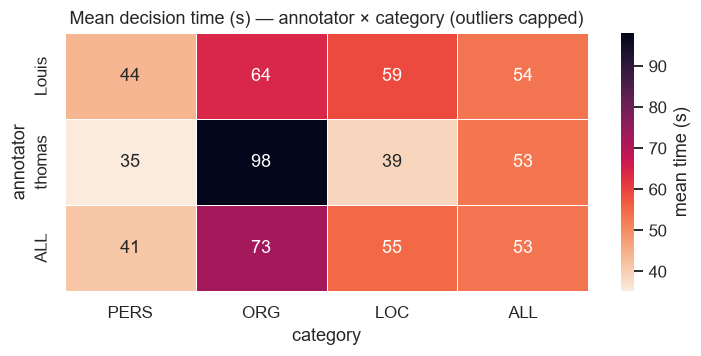

In [39]:
_base = times_df.pivot_table(index="annotator", columns="category", values="t", aggfunc="mean")
_cats = [c for c in ["PERS", "ORG", "LOC"] if c in _base.columns]
time_matrix = _base[_cats].copy()
time_matrix["ALL"]        = times_df.groupby("annotator")["t"].mean()
_row                      = times_df.groupby("category")["t"].mean().reindex(_cats)
_row["ALL"]               = times_df["t"].mean()
time_matrix.loc["ALL"]    = _row

fig, ax = plt.subplots(figsize=(6.8, 3.4))
sns.heatmap(time_matrix, annot=True, fmt=".0f", cmap="rocket_r",
            linewidths=.5, cbar_kws={"label": "mean time (s)"}, ax=ax)
ax.set_title("Mean decision time (s) — annotator × category (outliers capped)")
ax.set_xlabel("category"); ax.set_ylabel("annotator")
plt.tight_layout(); plt.show()

### 7.3 — Distribution & mean ± std

Left: mean decision time with **± std** error bars (what was requested). Right: full
distribution (box + points) so the spread — and the capping — is visible.

C:\Users\lohubert\AppData\Local\Temp\ipykernel_21256\2132038667.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#333333'` for the same effect.

  sns.stripplot(data=times_df, x="category", y="t", hue="annotator", order=_cats,


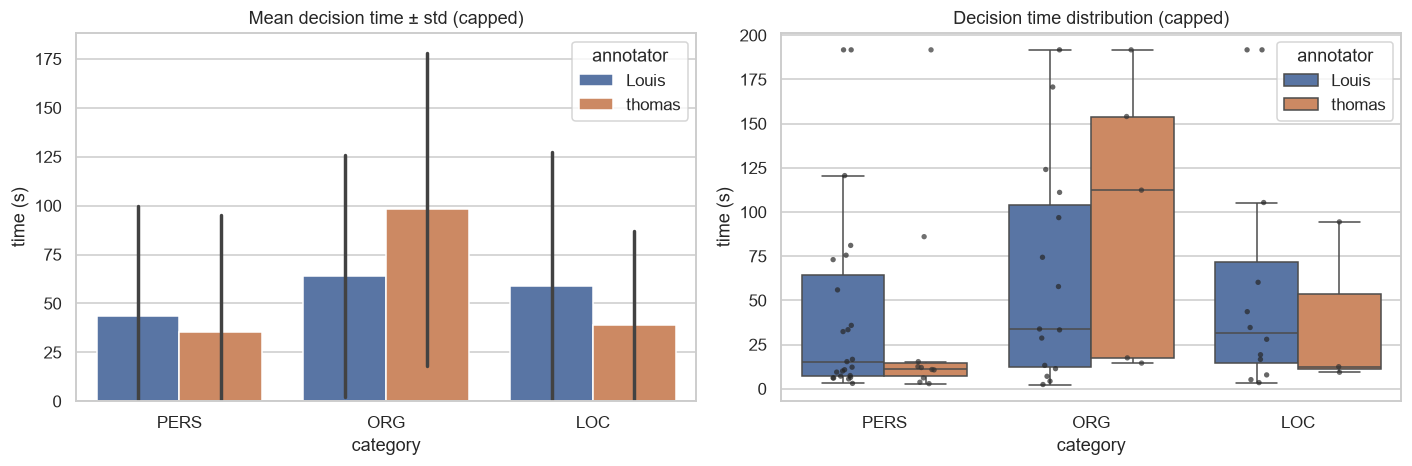

In [40]:
_cats = [c for c in ["PERS", "ORG", "LOC"] if c in times_df["category"].unique()]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

sns.barplot(data=times_df, x="category", y="t", hue="annotator", order=_cats,
            estimator="mean", errorbar="sd", ax=axes[0])
axes[0].set_ylim(bottom=0)
axes[0].set_title("Mean decision time ± std (capped)")
axes[0].set_xlabel("category"); axes[0].set_ylabel("time (s)")

sns.boxplot(data=times_df, x="category", y="t", hue="annotator", order=_cats,
            ax=axes[1], showfliers=False)
sns.stripplot(data=times_df, x="category", y="t", hue="annotator", order=_cats,
              dodge=True, color="#333333", size=3.5, alpha=.7, ax=axes[1], legend=False)
axes[1].set_title("Decision time distribution (capped)")
axes[1].set_xlabel("category"); axes[1].set_ylabel("time (s)")

plt.tight_layout(); plt.show()